# Quick-look for KUL-TN-20 simulations

This notebook can be used to have a quicklook at the that product for the simulations described in PLATO-PL-TN-0020. Note that the `LightCurve` class used to analyse the data assumes a identical structure of the data products as they are delivered on the KU Leuven FTP server.

### Setup notebook

In [8]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [9]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PlatoSim libraries
from platosim.lightcurve import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

## Load light curves for one star

In [161]:
# Load all data for a single star
idir = "/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000002"
lcs = LightCurve(idir, mode="multi")
# To fetch a specific light curve, use instead:
# lc = LightCurve(f"{idir}/000000083/000000083_Ncam1.1_Q23.ftr")

In [162]:
# Unzip all compressed files for the same star
lcs.unpack()

In [109]:
# Fetch all feather filenames
filenames = lcs.files("ftr")
filename  = filenames[0]
filenames

array(['/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000001/000000001_Ncam1.1_Q23.ftr',
       '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000001/000000001_Ncam1.2_Q23.ftr',
       '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000001/000000001_Ncam1.3_Q23.ftr',
       '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000001/000000001_Ncam1.4_Q23.ftr',
       '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000001/000000001_Ncam1.5_Q23.ftr',
       '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000001/000000001_Ncam1.6_Q23.ftr',
       '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000001/000000001_Ncam2.1_Q23.ftr',
       '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000001/000000001_Ncam2.2_Q23.ftr',
       '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000001/000000001_Ncam2.3_Q23.ftr',
       '/STER/platodata/PLATOSIM/simu

## Single N-CAM and Single Quarter

In [110]:
# Fetch the first light curve for this star
lc = LightCurve(filename)
lc.data().head()

,index,time,flux,xc,yc,flux_cor
0,0,171072012.5,208654.099401,3.175507,2.470957,1.095729
1,1,171072037.5,208811.909410,3.170680,2.470808,1.095746
2,2,171072062.5,208601.931723,3.171277,2.473429,1.095846
3,3,171072087.5,208934.735701,3.172316,2.469960,1.095980
4,4,171072112.5,208986.479717,3.169264,2.471522,1.095868


In [112]:
# Get target star information
star = lc.star_info(lcs.files("cat")[0])
print(f"""
Pmag : {star[0]}
rOA  : {star[1]}
rCOB : {star[2]}
nCon : {star[3]}
rCon : {star[4]}
dMag : {star[5]}
SPR  : {star[6]}
""")


Pmag : 10.55
rOA  : 17.411426181465878
rCOB : 0.23308638296441053
nCon : 0
rCon : 0
dMag : 0
SPR  : 0



In [113]:
# Get noise-less light curve
lc.varsource()

,time,spot,gran,puls,sum
0,171072000.0,-174.498085,-68.726698,-5.906176,-249.130959
1,171072025.0,-174.511294,-65.706562,-2.269514,-242.487370
2,171072050.0,-174.524502,-63.225373,1.809735,-235.940140
3,171072075.0,-174.537709,-59.440507,5.894689,-228.083526
4,171072100.0,-174.550914,-56.912242,9.885346,-221.577810
...,...,...,...,...,...
622075,186623875.0,-332.561564,-53.013986,17.884805,-367.690744
622076,186623900.0,-332.568187,-62.306062,13.556005,-381.318244
622077,186623925.0,-332.574807,-63.129136,8.352514,-387.351429
622078,186623950.0,-332.581425,-64.359459,2.131086,-394.809797


<IPython.core.display.Javascript object>


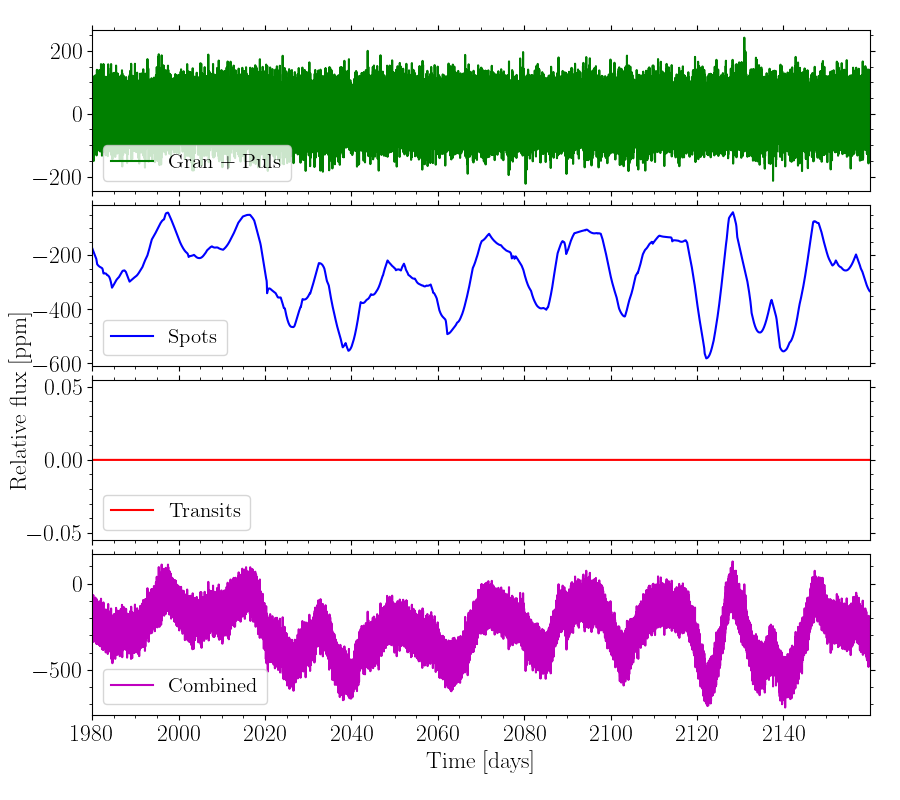

In [114]:
# Plot the input noise-less light curve
fig, ax = lc.plot_varsource();

<IPython.core.display.Javascript object>


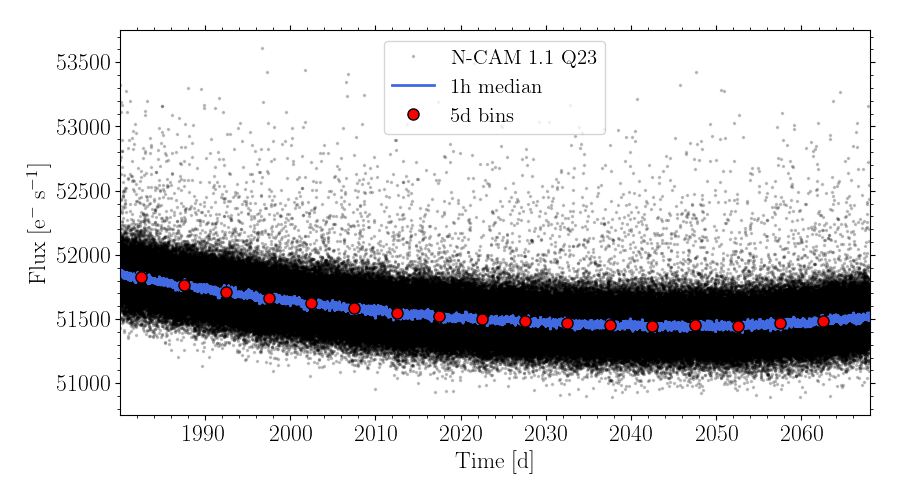

In [150]:
# Plot the simulation, running median, and binned data
fig, ax = lc.plot(time_unit="d", binsize=5, median_filter=1);

<IPython.core.display.Javascript object>


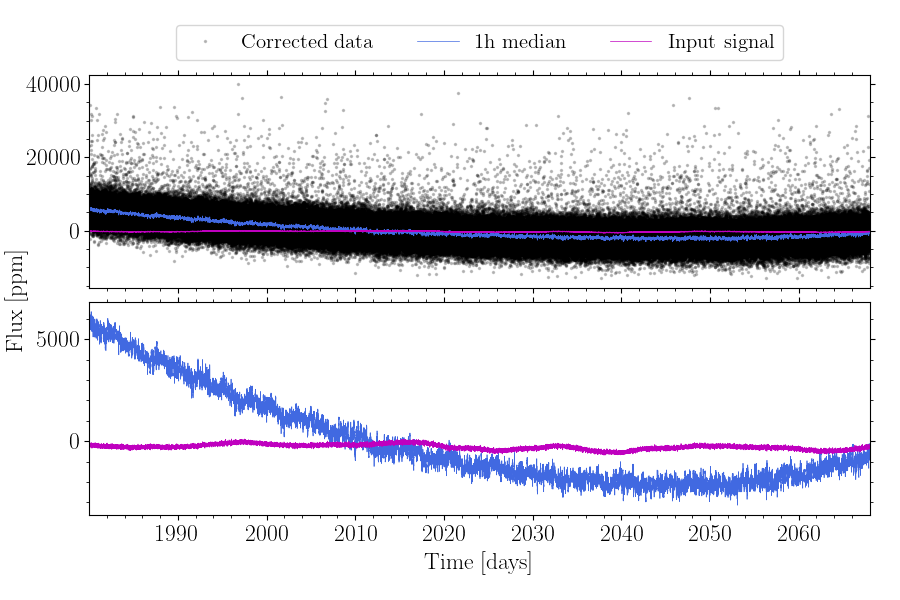

In [156]:
# Plot a quick O-C comparison plot 
fig, ax = lc.plot_oc();

<IPython.core.display.Javascript object>


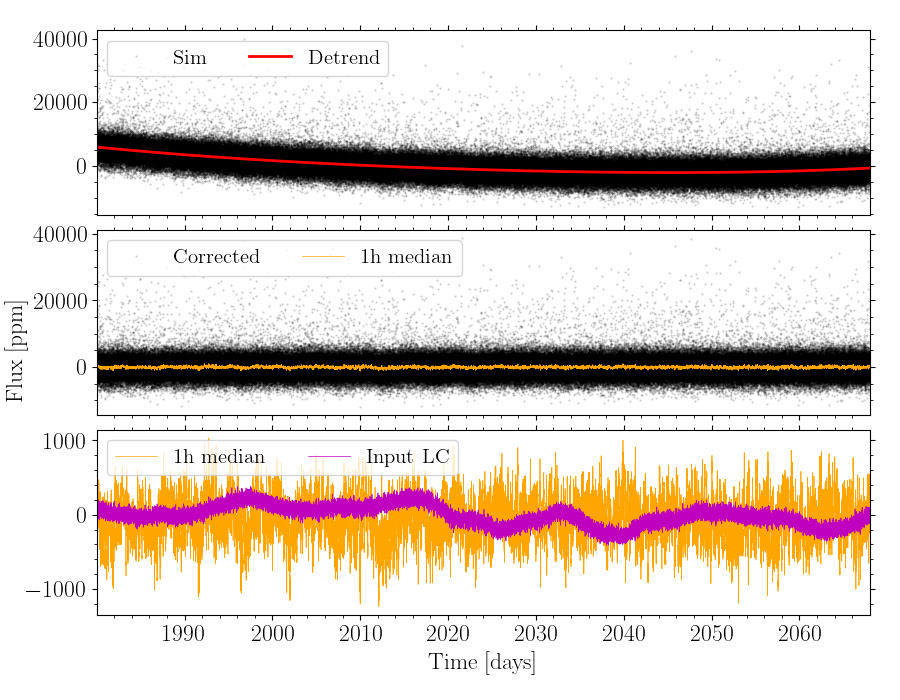

In [154]:
# Detrend light curve
lc.plot_detrend(poly_deg=4, binsize=1);

In [155]:
# Get NSR per 1h for detrended light curve 
lc.detrend(poly_deg=4)
lc.getNSR(column="flux_det", binhour=1, influx="ppm")

587.4126245356414

In [157]:
df = lc.data()
df["flux_det"].std()

594.8851563293169

In [158]:
# With the long trend systematics the NSR is somewhat larger
lc.getNSR()

2829.724499204392

## All N-CAMs and Single Qaurter

<IPython.core.display.Javascript object>


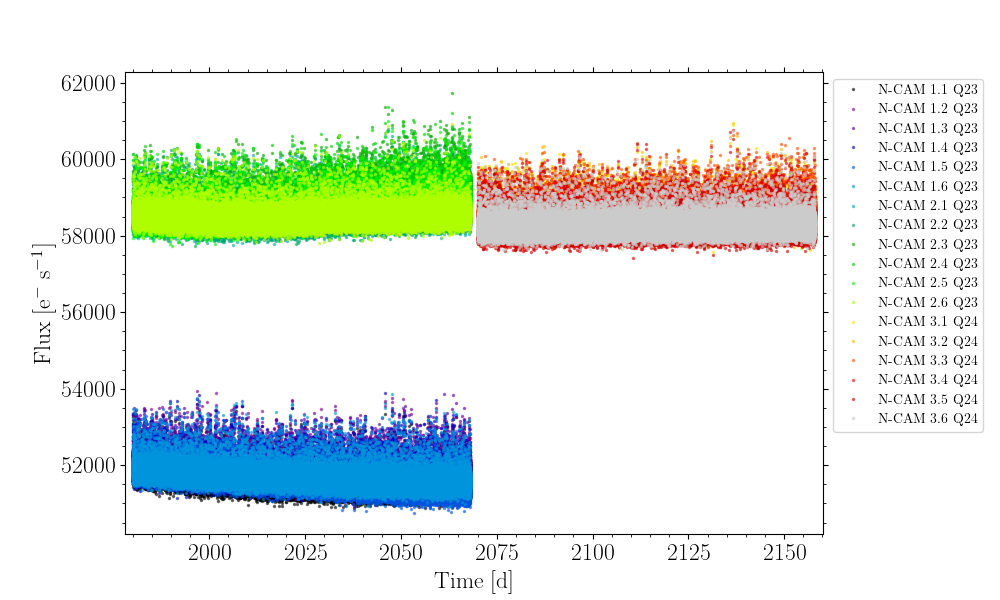

In [159]:
# Plot all light curves but for specific group, camera, or quarter
lcs.plot_multi(group=False, camera=False, quarter=False, flux_unit="e/s");

## Remember to remove unpacked files again!

In [160]:
# Remove files again to keep server clean
lcs.remove()